<a href="https://colab.research.google.com/github/ekaratnida/Applied-machine-learning/blob/master/Wee15/SHAP_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SHAP

## 1. Linear Regression

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [4]:
!ls /kaggle/input/california-housing-prices/

housing.csv


In [12]:
import sklearn
import shap
import pandas as pd

# a classic housing price dataset
df = pd.read_csv("/kaggle/input/california-housing-prices/housing.csv")
print(df.shape)
X1000 = df.sample(n=1000, random_state=1234)
X1000.dropna(inplace=True)
print(X1000.shape)

(20640, 10)
(991, 10)


In [22]:
X = X1000.drop(["median_house_value","ocean_proximity"], axis=1)
y = X1000["median_house_value"]
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
15712,-122.44,37.79,52.0,1726.0,384.0,614.0,356.0,3.6812
4119,-118.20,34.14,52.0,3800.0,646.0,1842.0,620.0,5.5524
15725,-122.44,37.78,44.0,1545.0,334.0,561.0,326.0,3.8750
14616,-117.17,32.80,20.0,2827.0,554.0,1822.0,536.0,3.4706
13238,-117.67,34.13,10.0,2846.0,362.0,1221.0,355.0,7.7234


In [23]:
y

,median_house_value
15712,500000.0
4119,293900.0
15725,412500.0
14616,157600.0
13238,304100.0
...,...
10708,72300.0
14185,98900.0
6594,500001.0
16414,137500.0


In [15]:
X100 = shap.utils.sample(X, 100)  # 100 instances for use as the background distribution

# a simple linear model
model = sklearn.linear_model.LinearRegression()
model.fit(X, y)

LinearRegression()

In [16]:
print("Model coefficients:\n")
for i in range(X.shape[1]):
    print(X.columns[i], "=", model.coef_[i].round(5))

Model coefficients:

longitude = -43168.4662
latitude = -44165.13259
housing_median_age = 1190.5909
total_rooms = 0.30671
total_bedrooms = 56.80939
population = -52.94402
households = 99.37851
median_income = 38065.95099


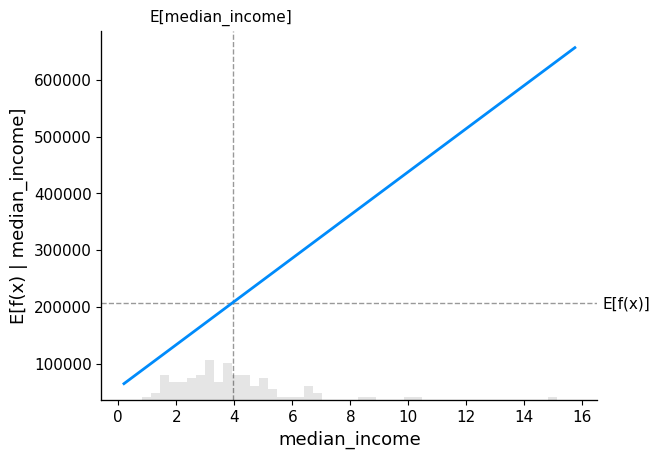

In [27]:
shap.partial_dependence_plot(
    "median_income",
    model.predict,
    X100,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [31]:
# compute the SHAP values for the linear model
explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)
print(shap_values)

991


In [32]:
# make a standard partial dependence plot
sample_ind = 1

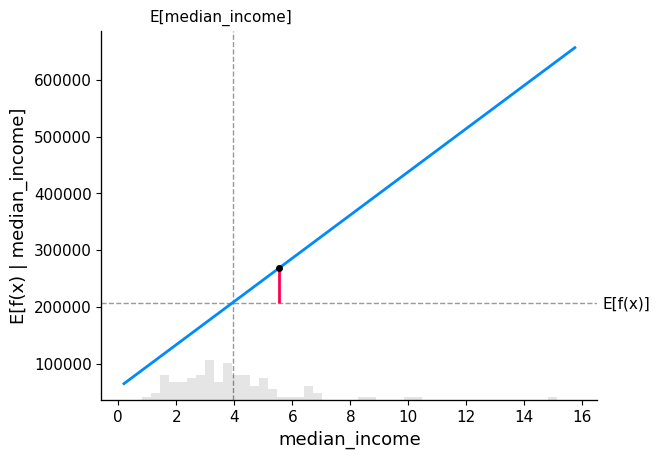

In [34]:
shap.partial_dependence_plot(
    "median_income",
    model.predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

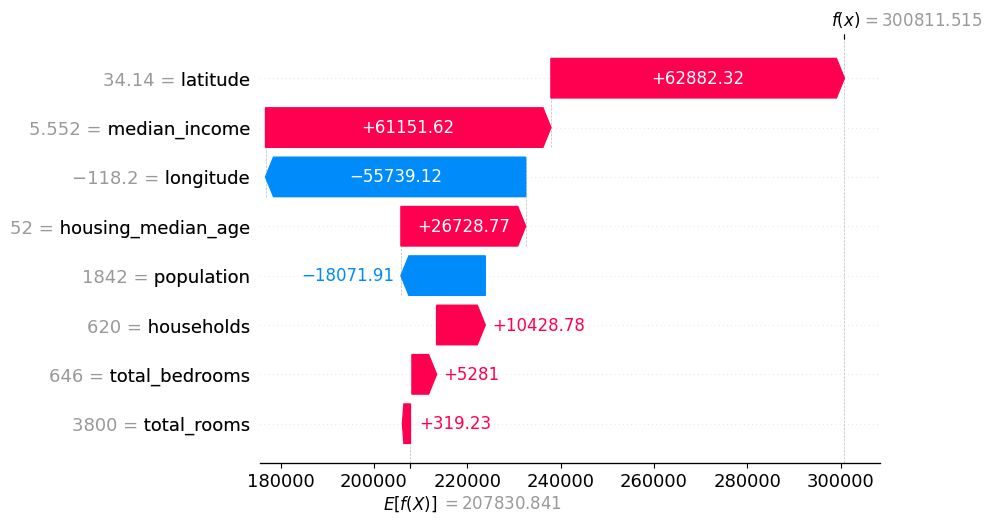

In [35]:
# the waterfall_plot shows how we get from shap_values.base_values to model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

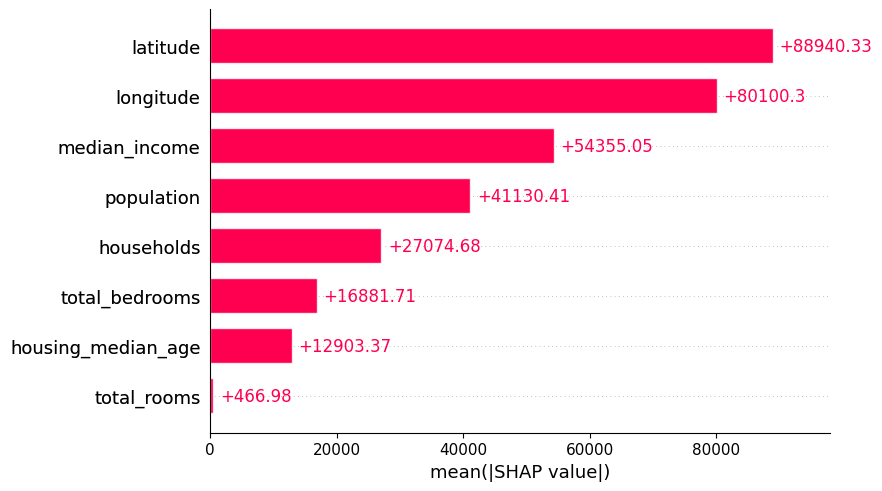

In [36]:
shap.plots.bar(shap_values)

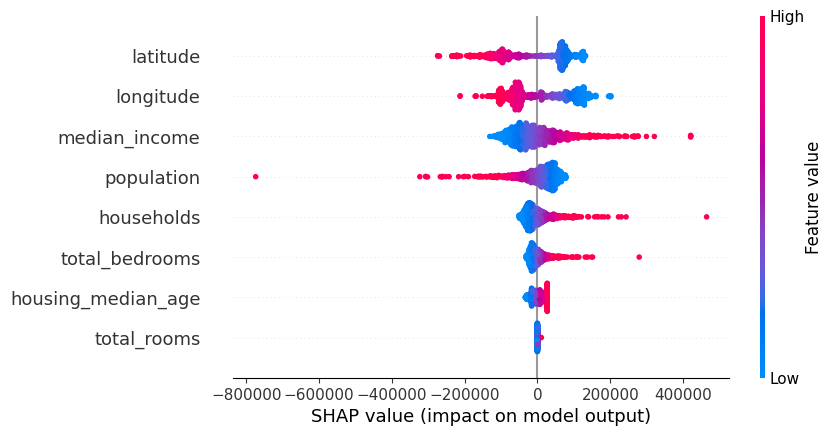

In [37]:
shap.plots.beeswarm(shap_values)

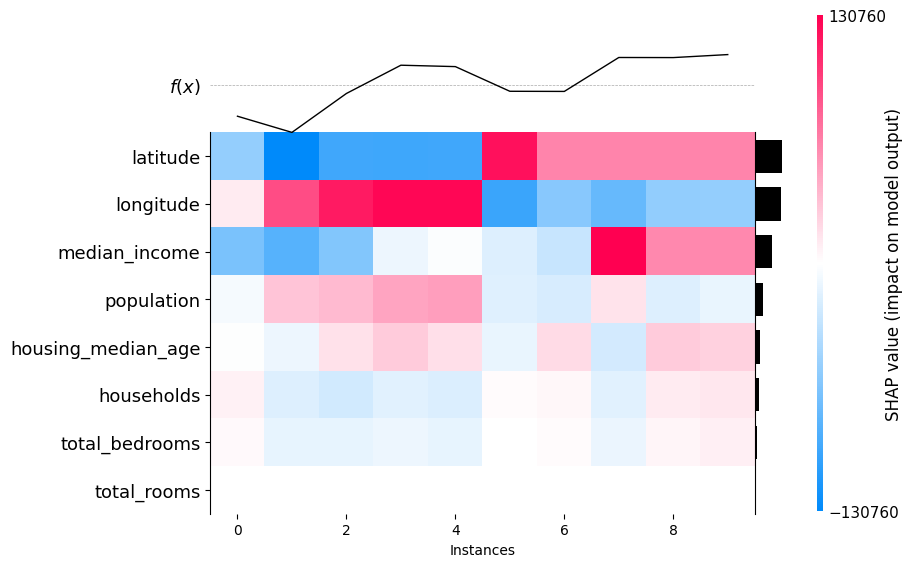

<Axes: xlabel='Instances'>

In [39]:
shap.plots.heatmap(shap_values[:10])

## 2. Logistic Regression

The original data includes the following columns:


Age (float) : Age in years.

Workclass (category) : Type of employment.

fnlwgt (float) : Final weight; the number of units in the target population that the record represents.

Education (category) : Highest level of education achieved.

Education-Num (float) : Numeric representation of education level.

Marital Status (category) : Marital status of the individual.

Occupation (category) : Type of occupation.

Relationship (category) : Relationship status.

Race (category) : Ethnicity of the individual.

Sex (category) : Gender of the individual.

Capital Gain (float) : Capital gains recorded.

Capital Loss (float) : Capital losses recorded.

Hours per week (float) : Number of hours worked per week.

Country (category) : Country of origin.

Target (category) : Binary target variable indicating whether the individual earns more than 50K.

In [67]:
# a classic adult census dataset price dataset
X_adult, y_adult = shap.datasets.adult()

# a simple linear logistic model
model_adult = sklearn.linear_model.LogisticRegression(max_iter=10000,random_state=1)
model_adult.fit(X_adult, y_adult)


LogisticRegression(max_iter=10000, random_state=1)

In [68]:
def model_adult_proba(x):
    return model_adult.predict_proba(x)[:, 1]

def model_adult_log_odds(x):
    p = model_adult.predict_log_proba(x)
    return p[:, 1] - p[:, 0]

In [69]:
X_adult.head()

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5


In [70]:
y_adult

array([False, False, False, ..., False, False,  True])

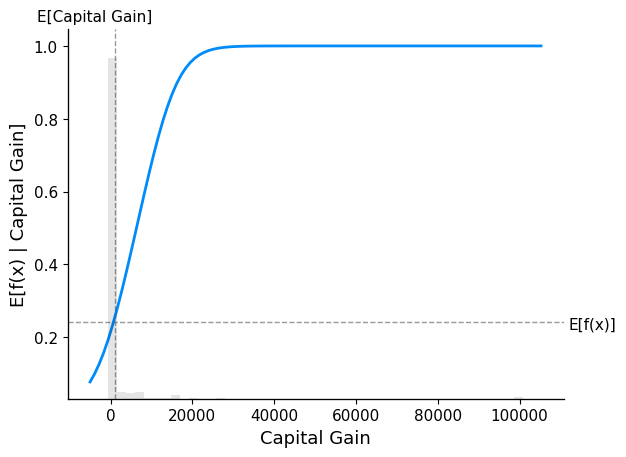

In [71]:
# make a standard partial dependence plot
fig, ax = shap.partial_dependence_plot(
    "Capital Gain",
    model_adult_proba,
    X_adult,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

In [72]:
# compute the SHAP values for the linear model
background_adult = shap.maskers.Independent(X_adult, max_samples=100)
explainer = shap.Explainer(model_adult_proba, background_adult)
shap_values_adult = explainer(X_adult[:1000])

PermutationExplainer explainer: 1001it [00:24, 24.25it/s]                         


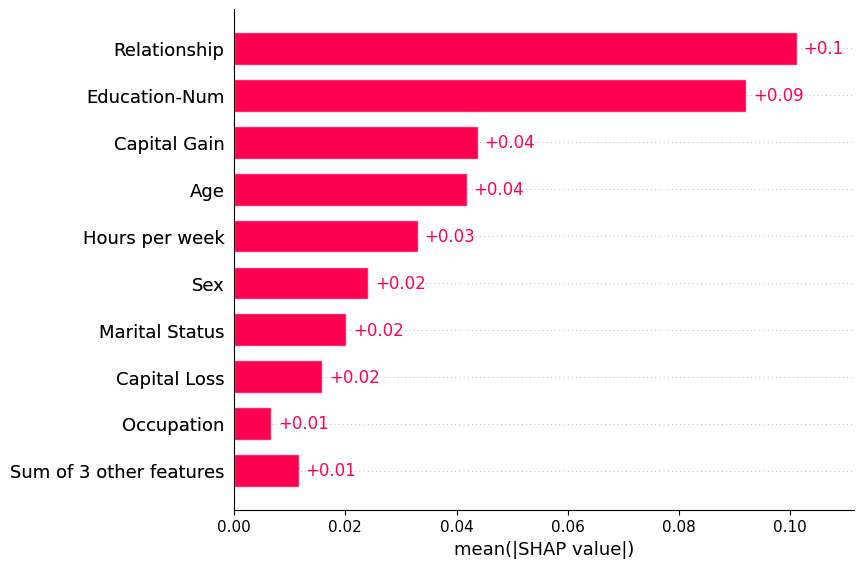

In [73]:
shap.plots.bar(shap_values_adult)

In [74]:
sample_ind = 10

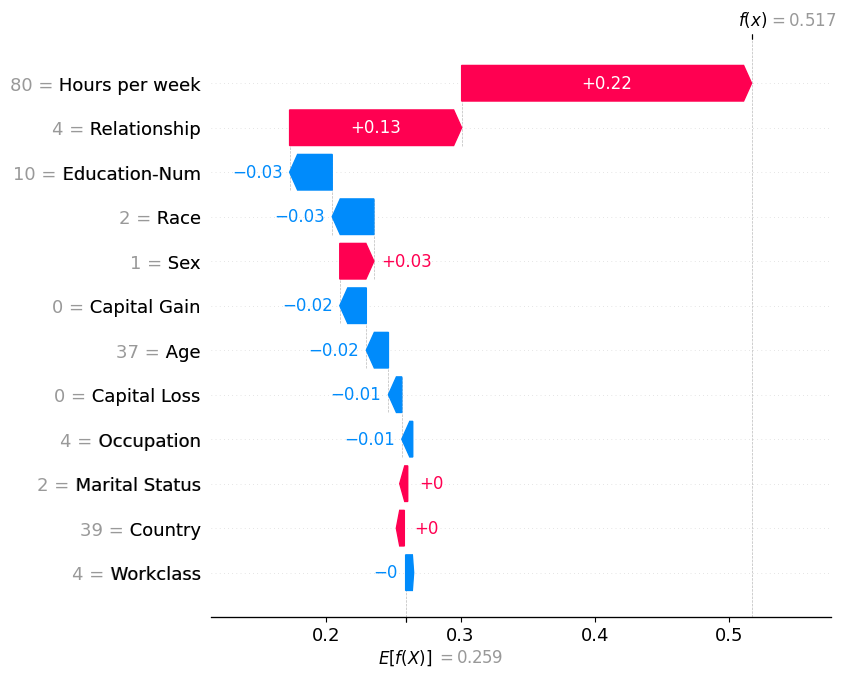

In [75]:
shap.plots.waterfall(shap_values_adult[sample_ind], max_display=14)

#Imbalanced dataset

In [ ]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=20, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

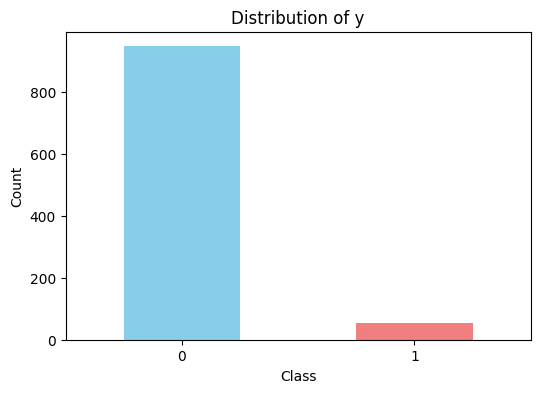

In [83]:
import matplotlib.pyplot as plt
import pandas as pd

def plotBar(y):
  # Convert y to a pandas Series to easily get value counts
  y_series = pd.Series(y)

  # Get the counts of each unique value in y
  value_counts = y_series.value_counts()

  # Plot a bar chart
  plt.figure(figsize=(6, 4))
  value_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
  plt.title('Distribution of y')
  plt.xlabel('Class')
  plt.ylabel('Count')
  plt.xticks(rotation=0)
  plt.show()

plotBar(y)

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

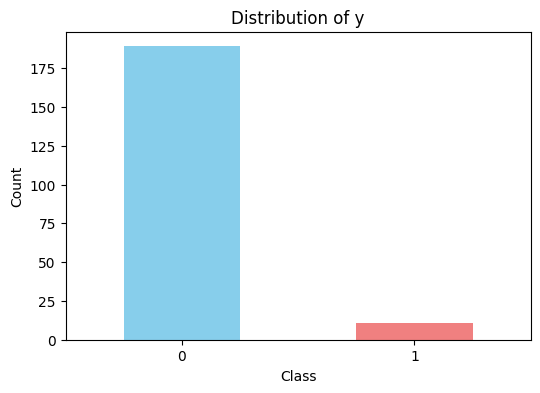

In [96]:
plotBar(y_test)

In [97]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(class_weight='balanced')
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [98]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
brf.fit(X_train, y_train)

BalancedRandomForestClassifier(random_state=42)

In [101]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

steps = [
    ('over', SMOTE(sampling_strategy=0.1)),
    ('model', LogisticRegression())
]

pipe = Pipeline(steps=steps)
pipe.fit(X_train, y_train)

Pipeline(steps=[('over', SMOTE(sampling_strategy=0.1)),
                ('model', LogisticRegression())])

In [102]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

steps = [
    ('under', RandomUnderSampler(sampling_strategy=0.5)),
    ('model', LogisticRegression())
]

pipe = Pipeline(steps=steps)
pipe.fit(X_train, y_train)

Pipeline(steps=[('under', RandomUnderSampler(sampling_strategy=0.5)),
                ('model', LogisticRegression())])

In [107]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

steps = [
    ('over', SMOTE(sampling_strategy=0.1)),
    ('under', RandomUnderSampler(sampling_strategy=0.5)),
    ('model', LogisticRegression())
]

pipe = Pipeline(steps=steps)
lrm = pipe.fit(X_train, y_train)
y_pred = lrm.predict(X_test)

In [108]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92       189
           1       0.16      0.36      0.22        11

    accuracy                           0.86       200
   macro avg       0.56      0.63      0.57       200
weighted avg       0.92      0.86      0.88       200

ROC AUC: 0.7941317941317941


In [112]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(clf, cv=5)
m = calibrated.fit(X_train, y_train)

In [113]:
y_pred = m.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       189
           1       0.00      0.00      0.00        11

    accuracy                           0.94       200
   macro avg       0.47      0.50      0.49       200
weighted avg       0.89      0.94      0.92       200

ROC AUC: 0.7941317941317941


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
